# Introduction to Machine Learning for Neuroscience
# Home Assingment 5
**19/01/2025** 

**Gilad Shilo ID: 318337136**

**Iakov Odesser ID: 209860288**

## Q1



a. TfIDF on the dataset, using only unigrams. Also translate categorical "Was reel Successful?" to binary

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load the dataset
df = pd.read_csv("reel_synopses_synthetic_dataset.csv")

# 2. Encode the target variable (Yes=1, No=0)
df['target'] = df['was_that_reel_very_successful'].map({'Yes': 1, 'No': 0})

# 3. Initialize TF-IDF Vectorizer
# stop_words='english' removes common words like 'and', 'the', etc.
tfidf = TfidfVectorizer(stop_words='english')

# Transform the 'synopsis' text into a feature matrix (X)
X = tfidf.fit_transform(df['synopsis'])
y = df['target']

# Convert to a DataFrame just to see the "tabular form" (Optional, for visualization)
X_df = pd.DataFrame(X.toarray(), columns=tfidf.get_feature_names_out())

print(f"Data shape after TF-IDF: {X_df.shape}")
print(X_df.head())

Data shape after TF-IDF: (200, 199)
   angle  autumn  backyard     baker  baking  balcony  beach  bike      bird  \
0    0.0     0.0  0.306732  0.000000     0.0      0.0    0.0   0.0  0.000000   
1    0.0     0.0  0.000000  0.408886     0.0      0.0    0.0   0.0  0.000000   
2    0.0     0.0  0.000000  0.000000     0.0      0.0    0.0   0.0  0.326819   
3    0.0     0.0  0.000000  0.000000     0.0      0.0    0.0   0.0  0.000000   
4    0.0     0.0  0.000000  0.000000     0.0      0.0    0.0   0.0  0.000000   

   blank  ...  uninteresting     video  viewer  walking  wall   watcher  \
0    0.0  ...            0.0  0.000000     0.0      0.0   0.0  0.000000   
1    0.0  ...            0.0  0.263427     0.0      0.0   0.0  0.000000   
2    0.0  ...            0.0  0.000000     0.0      0.0   0.0  0.326819   
3    0.0  ...            0.0  0.000000     0.0      0.0   0.0  0.000000   
4    0.0  ...            0.0  0.000000     0.0      0.0   0.0  0.000000   

   watching    water  yoga  zoom

b. 80/20 split 

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model 1: Random Forest 

Random Forest Best Params: {'max_depth': None, 'n_estimators': 400}
Random Forest Test AUC: 0.9129

Top 10 Important Features (Random Forest):
   feature  mean_drop_auc       std
0   really       0.020833  0.009385
1   camera       0.019192  0.009744
2    laugh       0.017551  0.013368
3  happens       0.016288  0.008014
4     clip       0.014520  0.009351
5    smile       0.013763  0.013802
6  sibling       0.012500  0.002554
7      low       0.010859  0.003920
8    share       0.010354  0.010546
9   moment       0.009848  0.011720


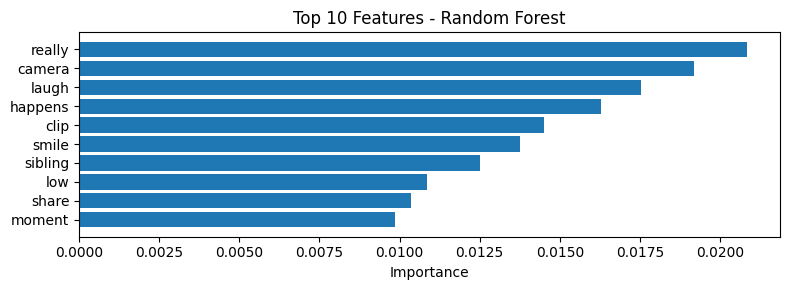

In [3]:
feature_names = tfidf.get_feature_names_out()

rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
}

# Grid Search with Cross Validation (CV)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# Evaluation
rf_best = rf_grid.best_estimator_
rf_pred_prob = rf_best.predict_proba(X_test)[:, 1]
print(f"Random Forest Best Params: {rf_grid.best_params_}")
print(f"Random Forest Test AUC: {roc_auc_score(y_test, rf_pred_prob):.4f}")


# Permutation importance (AUC drop) for Random Forest
rf_pi = permutation_importance(rf_best, X_test.toarray(), y_test,
                               scoring="roc_auc", n_repeats=10, n_jobs=-1, random_state=42)
rf_idx = rf_pi.importances_mean.argsort()[::-1][:10]
rf_top_features = pd.DataFrame({
    'feature': feature_names[rf_idx],
    'mean_drop_auc': rf_pi.importances_mean[rf_idx],
    'std': rf_pi.importances_std[rf_idx],
})

print("\nTop 10 Important Features (Random Forest):")
print(rf_top_features)

# Plot RF importances
plt.figure(figsize=(8, 3))
plt.barh(rf_top_features['feature'], rf_top_features['mean_drop_auc'])
plt.xlabel('Importance')
plt.title('Top 10 Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Model 2: Gradient Boosting

Gradient Boosting Best Params: {'learning_rate': 0.1, 'n_estimators': 100}
Gradient Boosting Test AUC: 0.8687

Top 10 Important Features (Gradient Boosting):
   feature  mean_drop_auc       std
0   moment       0.042929  0.021517
1    smile       0.035606  0.016692
2     clip       0.029798  0.011225
3  friends       0.015278  0.015541
4   camera       0.014646  0.013566
5    quiet       0.010985  0.008947
6    share       0.010101  0.007659
7     left       0.006566  0.006103
8  happens       0.006566  0.003779
9     pair       0.006313  0.002823


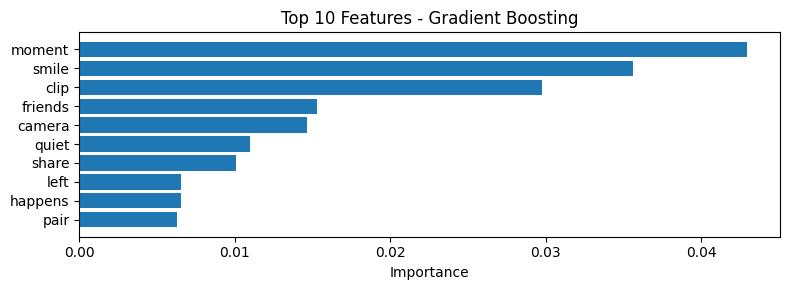

In [4]:
gb = GradientBoostingClassifier(random_state=42)
gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
}

gb_grid = GridSearchCV(gb, gb_params, cv=5, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train, y_train)

# Evaluation
gb_best = gb_grid.best_estimator_
gb_pred_prob = gb_best.predict_proba(X_test)[:, 1]
print(f"Gradient Boosting Best Params: {gb_grid.best_params_}")
print(f"Gradient Boosting Test AUC: {roc_auc_score(y_test, gb_pred_prob):.4f}")

# Permutation importance (AUC drop) for Gradient Boosting
gb_pi = permutation_importance(gb_best, X_test.toarray(), y_test,
                               scoring="roc_auc", n_repeats=10, n_jobs=-1, random_state=42)
gb_idx = gb_pi.importances_mean.argsort()[::-1][:10]
gb_top_features = pd.DataFrame({
    'feature': feature_names[gb_idx],
    'mean_drop_auc': gb_pi.importances_mean[gb_idx],
    'std': gb_pi.importances_std[gb_idx],
})

print("\nTop 10 Important Features (Gradient Boosting):")
print(gb_top_features)

# Plot GB importances
plt.figure(figsize=(8, 3))
plt.barh(gb_top_features['feature'], gb_top_features['mean_drop_auc'])
plt.xlabel('Importance')
plt.title('Top 10 Features - Gradient Boosting')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Using our parameters, the RF has outperformed GB by a slight margin (in AUC). 

c. Shap on doc 27 in the test set (69 in the original csv), Random Forest.

Document 27: A hiker is panning across an empty shelf at a local park. Nothing else really happens during the clip. There is no clear story or purpose.
Predicted P(successful): 0.043
Base value: 0.324


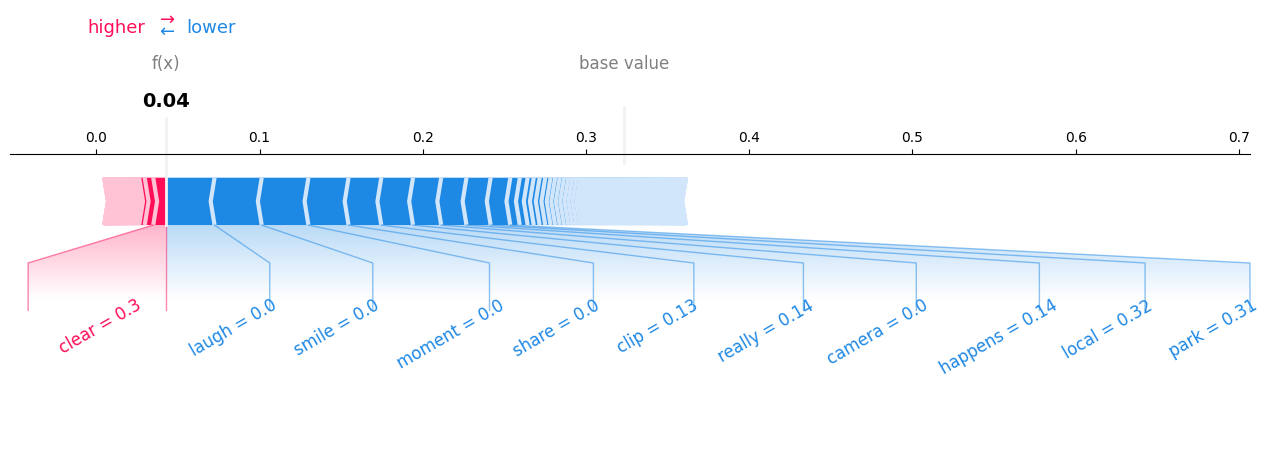

<Figure size 640x480 with 0 Axes>

In [5]:
import shap

shap.initjs()

# TreeExplainer on fitted RF
explainer = shap.TreeExplainer(rf_best)
X_test_dense = X_test.toarray().astype(float)

# Get SHAP values for class 1
shap_values_raw = explainer(X_test_dense)
sv1_all = shap_values_raw.values[:, :, 1]

# Choose one record
idx = 27
print(f"Document {idx}: {df.iloc[y_test.index[idx]]['synopsis']}")
print(f"Predicted P(successful): {rf_best.predict_proba(X_test_dense[idx:idx+1])[0, 1]:.3f}")
print(f"Base value: {explainer.expected_value[1]:.3f}")

# Round feature values so labels are readable
X_row_rounded = np.round(X_test_dense[idx, :], 2)

# Force plot with rounded values and rotated text
shap.force_plot(
    explainer.expected_value[1],
    sv1_all[idx, :],
    X_row_rounded,
    feature_names=list(feature_names),
    matplotlib=True,
    figsize=(16, 4),
    contribution_threshold=0.02,
    text_rotation=30,
)
plt.tight_layout()
plt.show()

d. We'll stick with the RF for this question as well 

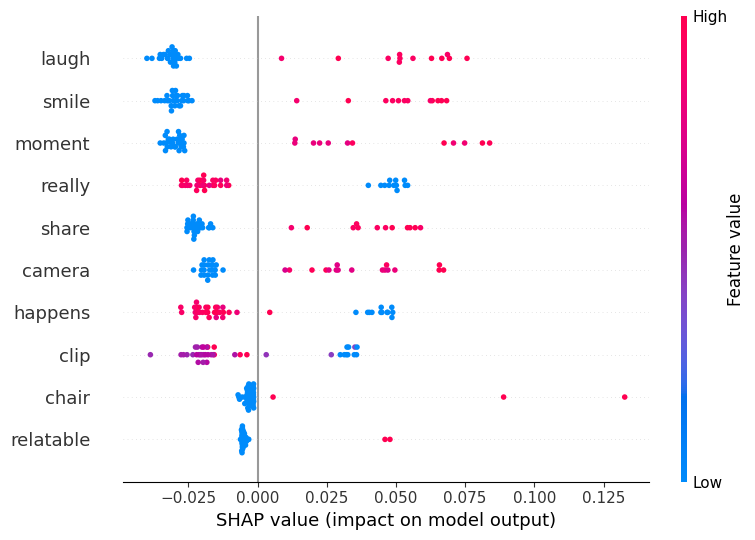

In [6]:
# Summary bar plot - top 10 most important features (global)
shap.summary_plot(sv1_all, X_test_dense, feature_names=list(feature_names), max_display=10)

as we can see there're some differences between this and permuation importance from earlier. However, the overlap is fairly large: 

In [7]:
# Compare top 10 features from both methods
print("Permutation Importance Top 10:")
print(list(rf_top_features['feature']))

shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(sv1_all).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nSHAP Top 10:")
print(list(shap_importance['feature'].head(10)))

# Overlap
overlap = set(rf_top_features['feature']) & set(shap_importance['feature'].head(10))
print(f"\nOverlap: {len(overlap)} features — {overlap}")

Permutation Importance Top 10:
['really', 'camera', 'laugh', 'happens', 'clip', 'smile', 'sibling', 'low', 'share', 'moment']

SHAP Top 10:
['laugh', 'smile', 'moment', 'really', 'share', 'camera', 'happens', 'clip', 'chair', 'relatable']

Overlap: 8 features — {'laugh', 'really', 'moment', 'share', 'happens', 'clip', 'camera', 'smile'}


## Q2


b. replicating the heatmap: 

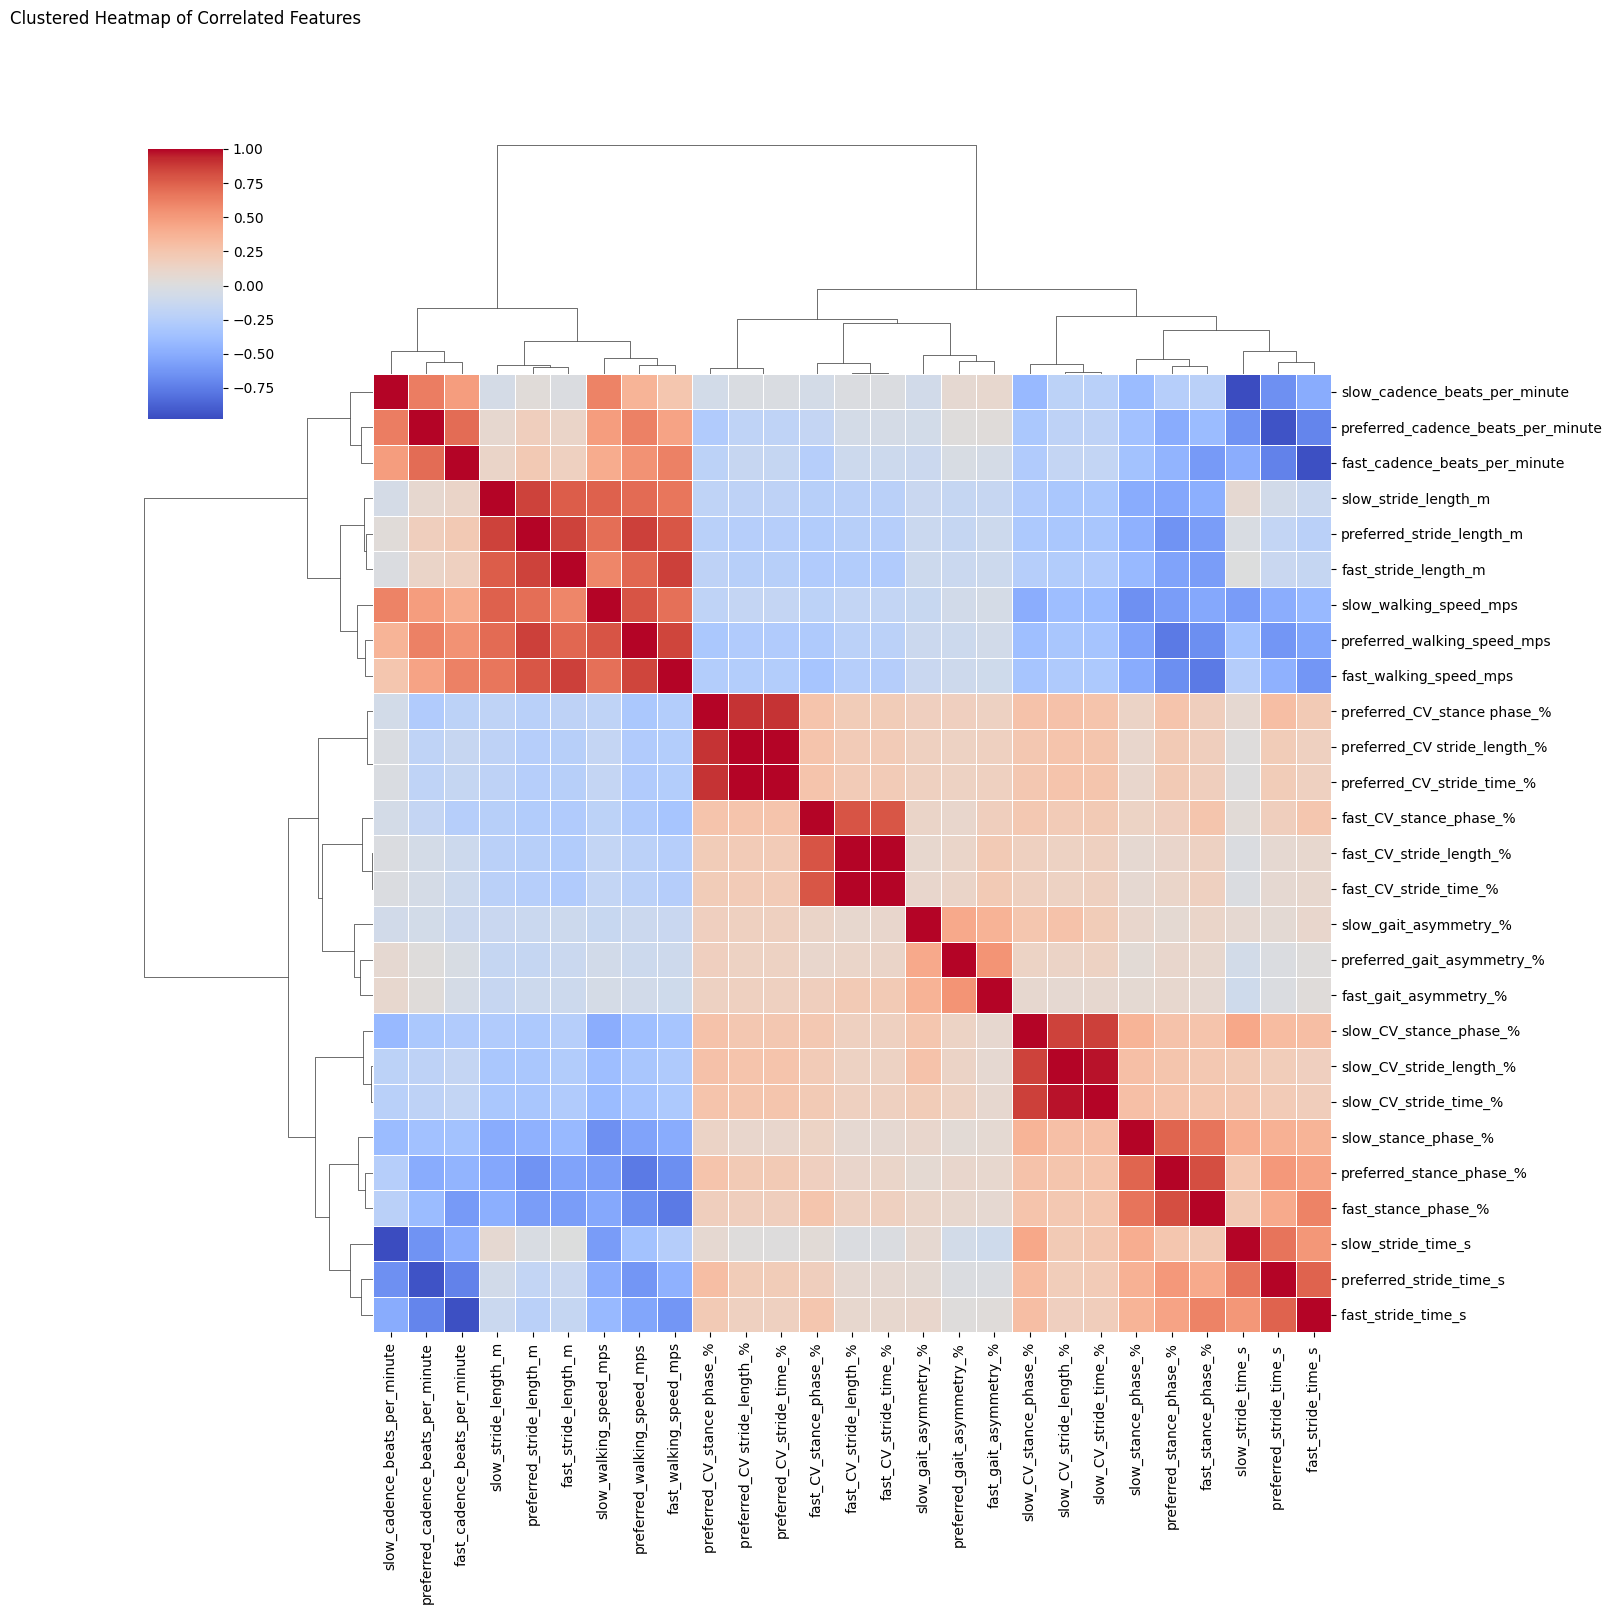

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_excel("41598_2021_91797_MOESM1_ESM.xlsx", header=1)  

# Select columns related to 'slow', 'preferred', and 'fast' walking speeds
columns_of_interest = [col for col in df.columns if "slow" in col.lower() or "preferred" 
in col.lower() or "fast" in col.lower()]
df_subset = df[columns_of_interest]

# Calculate the Pearson correlation matrix for the subset
corr_matrix_subset = df_subset.corr()

# Generate the clustered heatmap with hierarchical clustering applied to both rows and columns
clustermap = sns.clustermap(corr_matrix_subset, method='ward', cmap='coolwarm', figsize=
(15, 15), linewidths=.5)
plt.title('Clustered Heatmap of Correlated Features', pad=90)
plt.show()


c. The scatter plot where the axes are the first and second principal components scores 

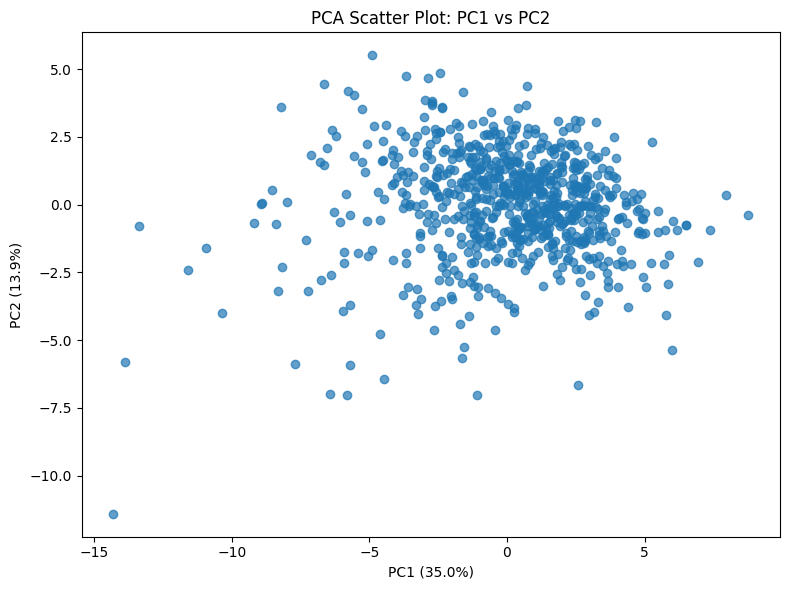

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize and apply PCA 
X_scaled = StandardScaler().fit_transform(df_subset.dropna())
pca = PCA().fit(X_scaled)
scores = pca.transform(X_scaled)

# Scatter plot of PC1 vs PC2
plt.figure(figsize=(8, 6))
plt.scatter(scores[:, 0], scores[:, 1], alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Scatter Plot: PC1 vs PC2')
plt.tight_layout()
plt.show()

(ii). The loadings: 

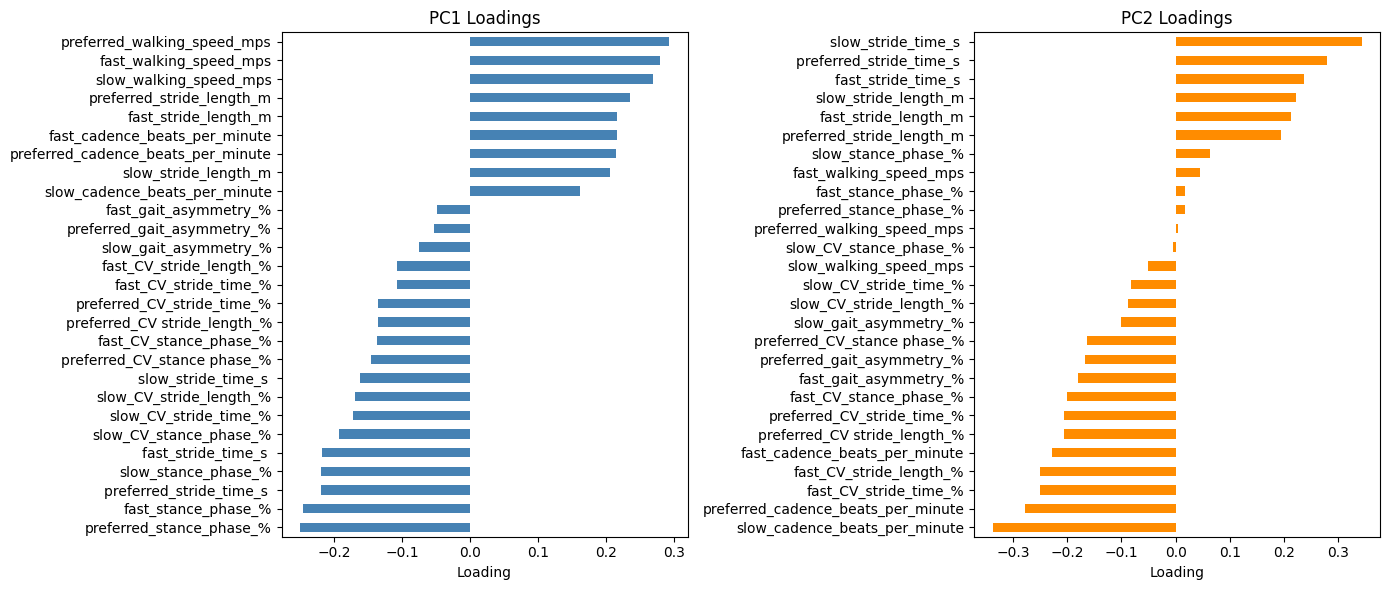

In [10]:
# Plot loadings for PC1 and PC2
loadings = pd.DataFrame(pca.components_[:2].T, index=df_subset.columns, columns=['PC1', 'PC2'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
loadings['PC1'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('PC1 Loadings')
axes[0].set_xlabel('Loading')

loadings['PC2'].sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('PC2 Loadings')
axes[1].set_xlabel('Loading')

plt.tight_layout()
plt.show()

There isn't a simple intuitive interpretation for the loadings demonstrated above, however the best verbal descriptions of PC1 and PC2 is as follows:  
PC1: Overall walking ability (fast & efficient vs. slow & labored)  
PC2: Gait strategy preference (long-slow strides vs. short-quick steps)

(iii). Plotting the explained variance ratio: 

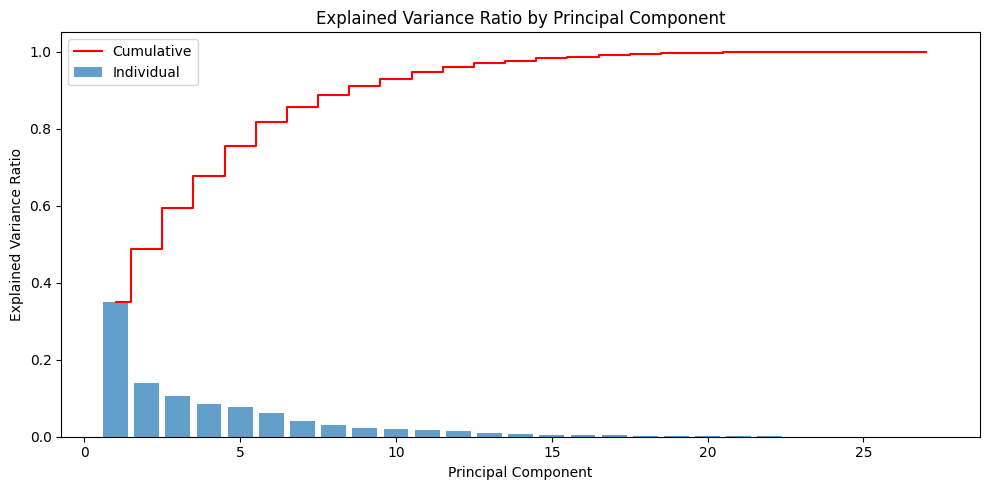

In [11]:

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.7, label='Individual')
plt.step(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), where='mid', label='Cumulative', color='red')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component')
plt.legend()
plt.tight_layout()
plt.show()

PC1 explains ~35% of the variance, and the first 5-6 components capture ~75% of total variance, indicating the data can be effectively reduced to a lower-dimensional representation while retaining most information.

(iv). K-means. We've deemed it correct to standardize even before original PCA to preven cadence's numerical dominance.

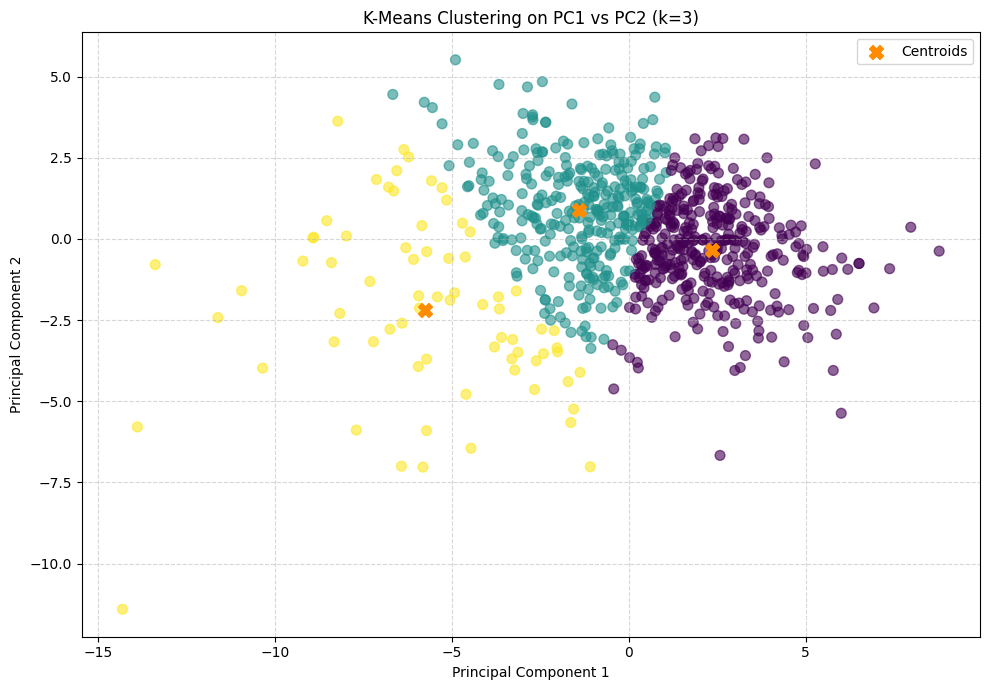

In [12]:
from sklearn.cluster import KMeans

# K-means on PC1 and PC2 (data already standardized via X_scaled)
X_pca = scores[:, :2]
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)
centers = kmeans.cluster_centers_

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, s=50)
plt.scatter(centers[:, 0], centers[:, 1], c='darkorange', marker='X', s=100, linewidths=1, label='Centroids')
plt.title(f'K-Means Clustering on PC1 vs PC2 (k={k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()